# Case study: the Kepler periodogram

Finding the period of a binary or planetary companion is usually the first step of an
orbit fit, and it often decides whether the rest of the analysis is tractable. `harv`
provides a Kepler periodogram for this: a period search built on the same linear-model
skeleton as Lomb–Scargle, but with a basis and a base model that are appropriate for
orbits and for real survey data. By default it integrates the orbit amplitudes out under
a prior rather than maximizing over them, and that prior can be made to know about
Kepler's third law.

This tutorial covers:
- Building the Fourier trial model, and why an eccentric orbit needs more than one harmonic,
- Running {py:func}`harv.periodogram.periodogram` in its default (marginal) mode and in
  profile mode (`prior=False`),
- Choosing `n_terms`, and what the statistic does when the data are sparse,
- Period-dependent amplitude priors that follow Kepler's third law,
- Applying the same machinery to Gaia epoch astrometry, and
- A worked example on Gaia BH3, where the orbital period is longer than the observing
  baseline.

Let's start with the imports we'll need. `matplotlib` comes with the `harv[extra]`
optional dependencies.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

In [2]:
import pathlib
import warnings

import astropy.table as at
import matplotlib.pyplot as plt
import numpy as np
import quaxed.numpy as jnp
from unxt import Q, ustrip

import harv
import harv.models as hm
import harv.periodogram as hp
from harv.kepler.body import KeplerianBody
from harv.simulate import (
    fake_parallax_factor,
    simulate_gaia_epoch_astrometry,
    simulate_rv_sb1_data,
)

# Keep the committed notebook under the repo's 2 MB file cap.
plt.rcParams["figure.dpi"] = 80

```{note}
The `jax_enable_x64` call above is not optional for periodogram work. In float32 the
$\Delta$ values computed below overflow when exponentiated, and harv raises an error
pointing at exactly this line.
```

## 1. Why a Kepler periodogram?

It helps to recall what Lomb–Scargle actually is, stripped of its history as a
generalization of the Fourier transform. At each trial frequency $\nu$ it fits a linear
model

$$y(t) = a\cos(2\pi\nu t) + b\sin(2\pi\nu t) + c$$

by least squares, and reports how much the fit improved on a constant-only model. In
other words, it is a linear-model periodogram: build a design matrix at each trial
frequency, minimize $\chi^2$, and report the improvement. Nothing about that skeleton is
specific to sinusoids.

Two things break when the signal is an orbit. The first is that an eccentric orbit is
not a sinusoid. Its radial-velocity curve is periodic, so all of its power sits at
harmonics of the orbital frequency, but a $[\cos, \sin]$ basis can only see the
fundamental. The more eccentric the orbit, the more of its signal is invisible to that
basis. Let's look at that directly, using harv's own orbit machinery to generate the RV
curves and a Fourier design matrix whose columns match
{py:class}`~harv.models.FourierRV` column for column:

In [3]:
from harv.kepler.orbits import mean_anomaly, rv_shape, true_anomaly_from_mean


def design_matrix(t, t_ref, period, n_terms):
    """The (n_obs, 2*n_terms + 1) Fourier design matrix.

    Columns are ``[cos(k M), sin(k M)]`` for ``k = 1..n_terms`` plus a constant, where
    ``M = 2 pi (t - t_ref) / P`` is the mean longitude. This matches
    :class:`harv.models.FourierRV` column for column.
    """
    M = 2.0 * np.pi * (t - t_ref) / period
    cols = []
    for k in range(1, n_terms + 1):
        cols += [np.cos(k * M), np.sin(k * M)]
    cols.append(np.ones_like(t))
    return np.column_stack(cols)


def rv_curve(t, period, ecc, semiamp=1.0, t_peri=0.0, arg_peri=0.5):
    """A Keplerian RV curve, using harv's own orbit machinery."""
    M = mean_anomaly(Q(t - t_peri, "day"), Q(period, "day"))
    sin_f, cos_f = true_anomaly_from_mean(M, ecc)
    return semiamp * np.asarray(rv_shape(sin_f, cos_f, ecc, Q(arg_peri, "rad")))


def fourier_fit(t, y, period, n_terms):
    """Least-squares truncated Fourier series in the mean longitude."""
    X = design_matrix(t, 0.0, period, n_terms)
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return X @ coef

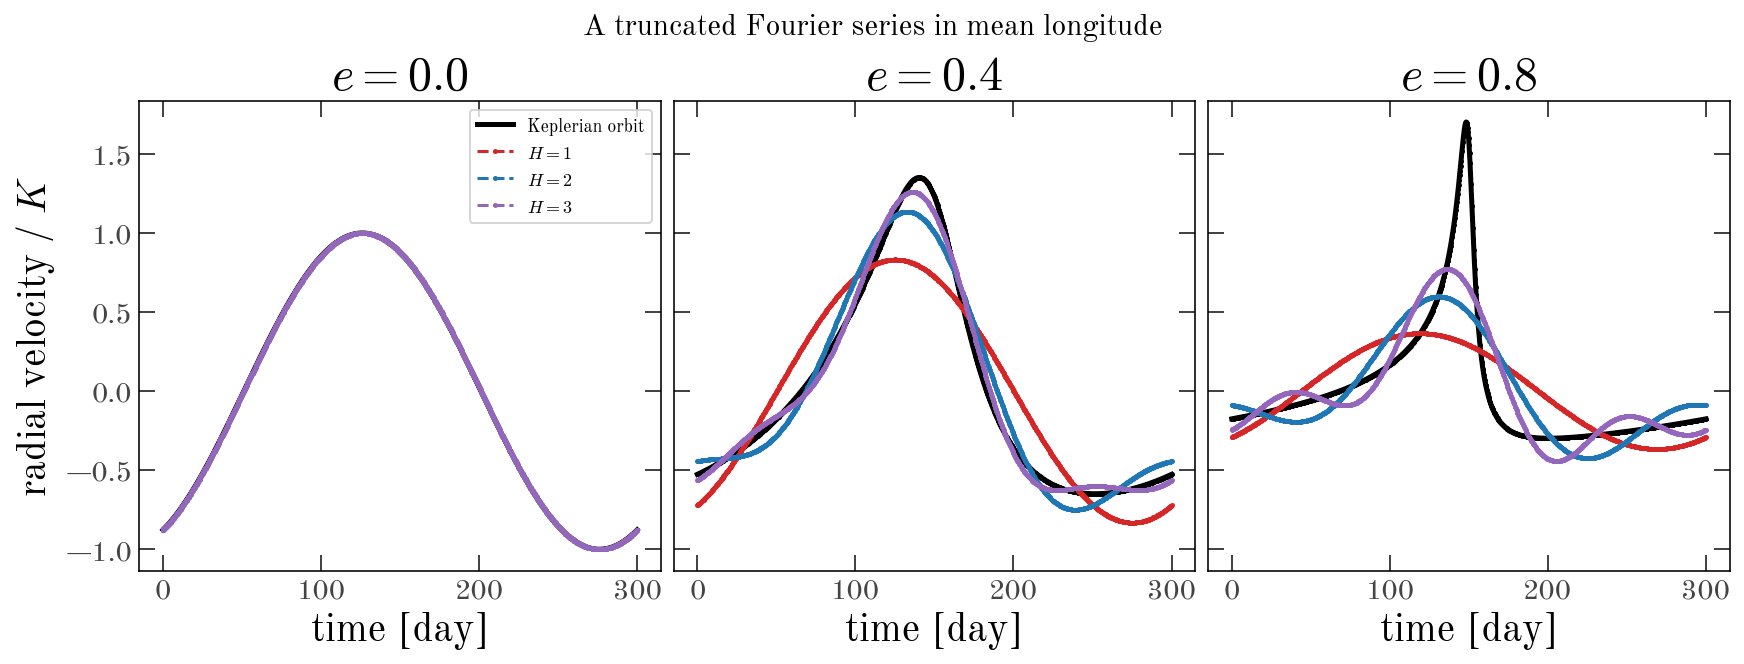

In [4]:
t_dense = np.linspace(0, 300, 1000)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), layout="constrained", sharey=True)
for ax, ecc in zip(axes, [0.0, 0.4, 0.8], strict=True):
    y = rv_curve(t_dense, 300.0, ecc, t_peri=150.0)
    ax.plot(t_dense, y, color="k", lw=2.5, label="Keplerian orbit")
    for n_terms, color in [(1, "tab:red"), (2, "tab:blue"), (3, "tab:purple")]:
        ax.plot(
            t_dense,
            fourier_fit(t_dense, y, 300.0, n_terms),
            color=color,
            lw=1.5,
            ls="--",
            label=f"$H={n_terms}$",
        )
    ax.set(xlabel="time [day]", title=f"$e = {ecc}$")
axes[0].set_ylabel("radial velocity / $K$")
axes[0].legend(fontsize=9)
_ = fig.suptitle("A truncated Fourier series in mean longitude", fontsize=15)

At $e = 0$ a single harmonic is the orbit: $H=1$ lies exactly on the black curve, and
that is the case Lomb–Scargle was built for. At $e = 0.8$ the single harmonic misses
badly, and each additional term recovers more of the shape.

This is the first half of the generalization: keep the linear-model skeleton, but use a
truncated Fourier series in the *mean longitude* $M = 2\pi(t - t_\mathrm{ref})/P$
instead of a single sinusoid. The periastron phase is absorbed into each $(\cos, \sin)$
amplitude pair, and the eccentricity distortion is absorbed by the $k > 1$ terms. No
Kepler solve happens anywhere, so every amplitude stays linear, which is what makes the
whole thing fast and analytically marginalizable. In harv these models are
{py:class}`~harv.models.FourierRV` and {py:class}`~harv.models.FourierGaiaAstrometry`.

The second thing that breaks, and the more important one in practice, is that real data
carry columns that have to be projected out rather than fit around. A Gaia
epoch-astrometry time series is dominated by parallax and proper motion, a
multi-instrument RV campaign has a different zero point per spectrograph, and many
systems have a long-term trend. None of these are the signal, and none of them are noise
either, so the periodogram has to hold a *base model* fixed underneath the trial orbit.
That is exactly what Lomb–Scargle's constant-only model is, generalized.

So a Kepler periodogram is a linear-model periodogram with (a) a harmonic basis and (b)
an arbitrary base model. Everything below follows from those two changes.

## 2. Marginalizing over the amplitudes

Once we have a design matrix $X(P)$ at a trial period, there is more than one thing we
can do with it, and the choice is what separates harv's periodogram from the classical
ones. Write $C$ for the (diagonal) noise covariance, $X_w = C^{-1/2}X$ for the whitened
design matrix, and $y_w = C^{-1/2}y$ for the whitened data.

The classical option is to profile (i.e., maximize): minimize $\chi^2$ over the linear
amplitudes and report the improvement over the base model,

$$z_0(\nu) = \tfrac{1}{2}\left[\chi^2_{\mathrm{base}} - \chi^2_{\mathrm{trial}}(\nu)\right] \quad .$$

This is a generalized likelihood ratio evaluated at the maximum-likelihood amplitudes.
Lomb–Scargle is the special case with one harmonic and a constant base model, and it is
what [kepmodel](https://gitlab.unige.ch/delisle/kepmodel/) reports (up to Baluev's
normalization, which divides by $\chi^2_\mathrm{base}$ to make the statistic invariant to
an unknown global noise scale). In harv, we get this statistic by passing `prior=False`.

The other option, and harv's default, is to marginalize (i.e., integrate): put a
Gaussian prior $\theta \sim \mathcal{N}(0, \Lambda)$ on the amplitudes and integrate them
out. With $L$ the prior scale (so $\Lambda = LL^\top$), $B = X_w L$, and
$M = I + B^\top B$,

$$\ln Z = -\tfrac{1}{2} y_w^\top y_w + \tfrac{1}{2} c^\top M^{-1} c - \tfrac{1}{2}\ln\det M + \mathrm{const}, \qquad c = B^\top y_w \quad ,$$

and the periodogram reports
$\Delta(\nu) = \ln Z_\mathrm{trial}(\nu) - \ln Z_\mathrm{base}$, a per-frequency log
Bayes factor of "base + orbit harmonics" against the base model alone.

These are two different quantities rather than two settings of one, and harv computes
them by separate code paths. In particular, the marginal statistic does not approach the
profile one as the priors widen: the trial model has more columns than the base model, so
the Occam factor grows without bound and
$\Delta \to z_0 - \tfrac{1}{2}(d_\mathrm{trial} - d_\mathrm{base})\ln\Lambda \to -\infty$.

Both statistics come out of the same design matrix, so let's simulate an eccentric
single-lined binary and run harv both ways on a single shared grid.

The amplitude prior is required and entirely explicit: harv never inspects the data to
pick a scale for us. There are two forms. The primary one, `sigma_K0` together with
`P0`, makes the amplitude prior shrink with period the way Kepler's third law says it
should, and we come back to it in section 5. Here we deliberately use the other form, a
flat `sigma_amp`, because with a period-independent prior the Occam penalty is nearly
constant across the grid, which makes the comparison against the profile statistic
cleaner.

In [5]:
SIGMA_AMP = Q(30.0, "km/s")
SIGMA_V0 = Q(50.0, "km/s")
PMIN, PMAX = Q(10.0, "day"), Q(2000.0, "day")

data, truth = simulate_rv_sb1_data(
    seed=42,
    n_obs=40,
    period=Q(150.0, "day"),
    eccentricity=0.6,
    rv_semiamp=Q(5.0, "km/s"),
    rv_err=Q(0.5, "km/s"),
    v_sys=Q(0.0, "km/s"),
)

# One grid, so the two statistics are compared point for point.
grid = hp.frequency_grid(data, period_min=PMIN, period_max=PMAX, samples_per_peak=5)

fourier_prior = hm.FourierRV(n_terms=2).default_prior(
    period_min=PMIN,
    period_max=PMAX,
    sigma_amp=SIGMA_AMP,
    sigma_v0=SIGMA_V0,
)
marginal = hp.periodogram(data, grid, prior=fourier_prior, n_terms=2)
profile = hp.periodogram(data, grid, prior=False, n_terms=2)

periods = np.asarray(ustrip("day", marginal.period))
delta = np.asarray(marginal.delta_ln_likelihood)
z0 = np.asarray(profile.delta_ln_likelihood)

print(f"grid points:      {len(periods)}")
for res in (marginal, profile):
    print(f"{res.statistic:>9} peak:  {float(ustrip('day', res.max_period())):8.2f} d")
print(f"injected period:  {float(ustrip('day', truth['period'])):8.2f} d")

grid points:      894
 marginal peak:    150.87 d
  profile peak:    150.87 d
injected period:    150.00 d


median offset, z0 - Delta:  22.25 nats
spread of that offset:      0.66 nats


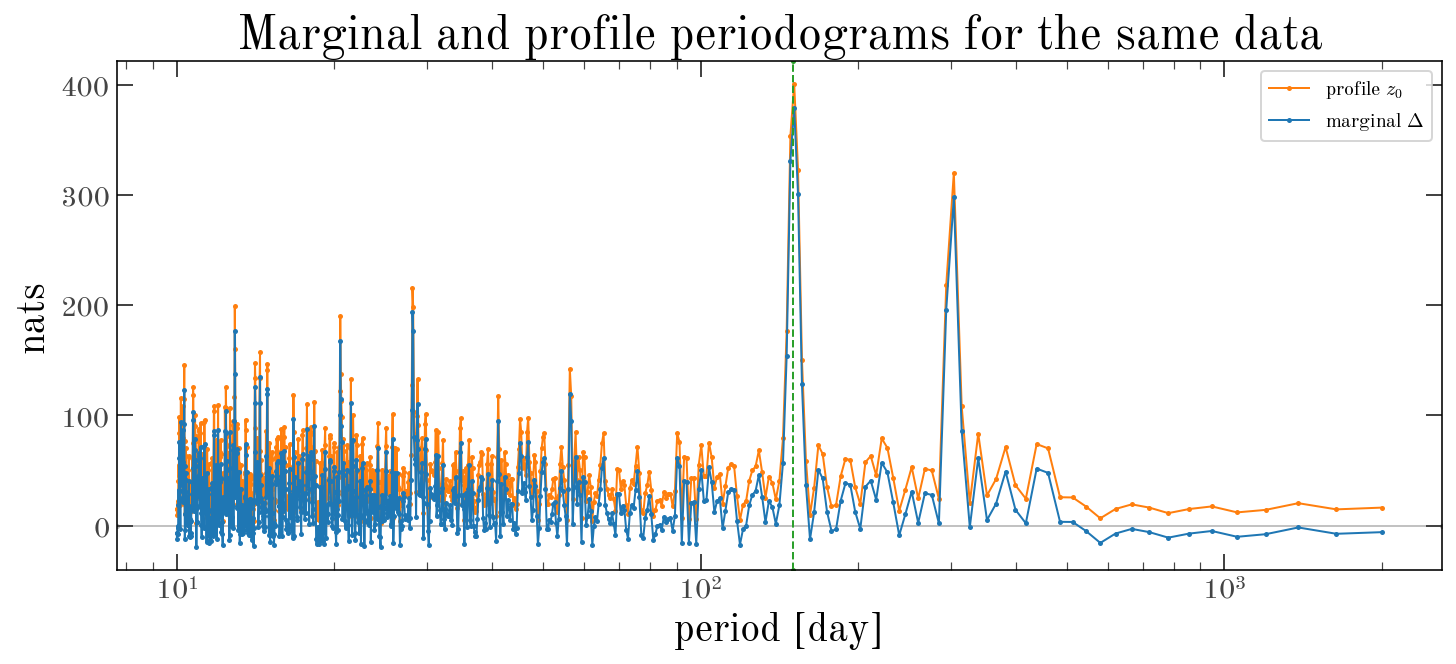

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.plot(periods, z0, color="tab:orange", lw=1, label=r"profile $z_0$")
ax.plot(periods, delta, color="tab:blue", lw=1, label=r"marginal $\Delta$")
ax.axhline(0.0, color="0.7", lw=0.8, zorder=0)
ax.axvline(float(ustrip("day", truth["period"])), color="tab:green", ls="--", lw=1)
ax.set(xlabel="period [day]", ylabel="nats", xscale="log")
ax.legend()
_ = ax.set_title("Marginal and profile periodograms for the same data")

print(f"median offset, z0 - Delta:  {np.median(z0 - delta):.2f} nats")
print(f"spread of that offset:      {np.ptp(z0 - delta):.2f} nats")

The two curves have the same structure but are separated by a nearly constant offset of
about 22 nats, which varies by well under a nat across the whole grid. That offset is the
Occam penalty the marginal likelihood charges for the four extra amplitude columns.

Note also that the profile curve never dips below zero while the marginal one does. This
is structural: the trial model nests the base model, so extra columns can only lower
$\chi^2$ and $z_0 \geq 0$ everywhere. $\Delta$ is free to go negative wherever the Occam
penalty outweighs the improvement in fit, which is the periodogram telling us that a
trial period is actively disfavored, something that $z_0$ cannot express.

The near-constancy of the offset is a property of this grid, which stops at 2000 d, and
not a theorem: push a grid well past the observing baseline and the harmonic columns go
collinear with the constant column, which gives the offset several nats of period
dependence even for a period-independent prior.

An offset in a log-likelihood is a rescaling of the corresponding likelihood, and a
rescaling vanishes as soon as we normalize. So let's normalize both, turning each
statistic into a density in $\ln P$, and zoom in on the peak.

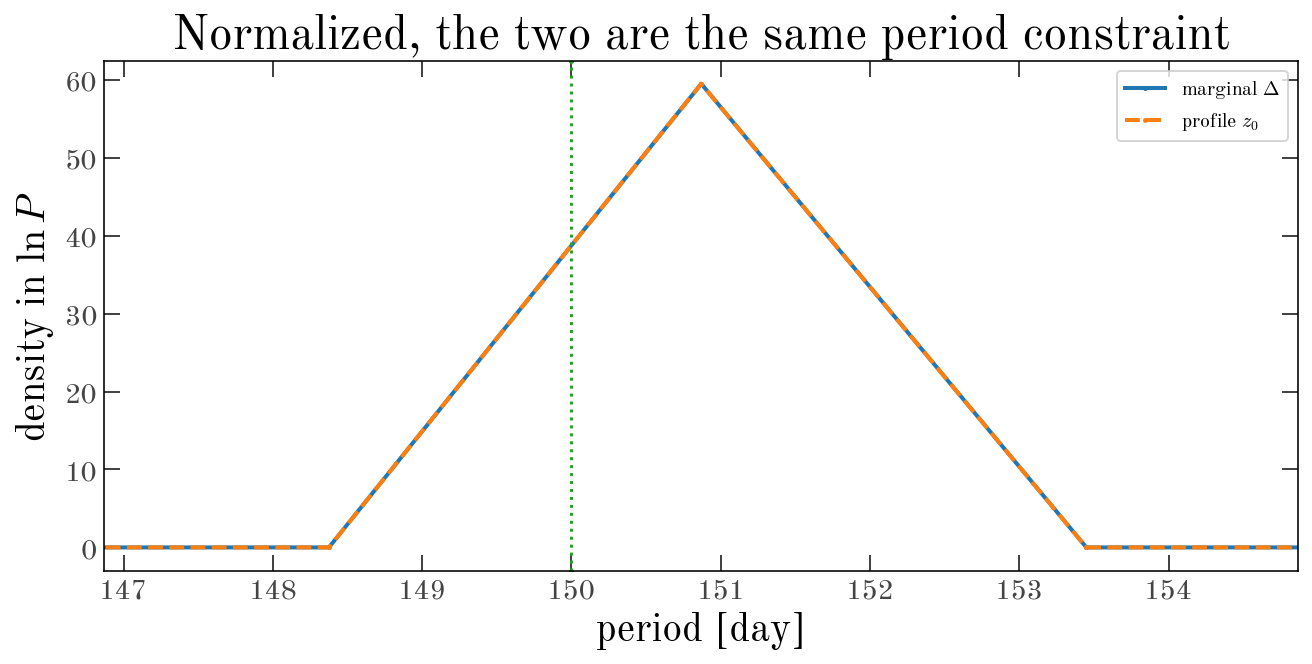

In [7]:
def ln_period_density(curve, periods):
    """Normalize exp(statistic) to a density per unit ln-period."""
    order = np.argsort(np.log(periods))
    dens = np.exp(curve - curve.max())
    return dens / np.trapezoid(dens[order], np.log(periods)[order])


peak = float(periods[delta.argmax()])
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
for label, curve, color, ls in [
    (r"marginal $\Delta$", delta, "tab:blue", "-"),
    (r"profile $z_0$", z0, "tab:orange", "--"),
]:
    ax.plot(
        periods,
        ln_period_density(curve, periods),
        color=color,
        ls=ls,
        lw=2,
        label=label,
    )
ax.axvline(float(ustrip("day", truth["period"])), color="tab:green", ls=":", lw=1.5)
ax.set(
    xlabel="period [day]", ylabel=r"density in $\ln P$", xlim=(peak - 4.0, peak + 4.0)
)
ax.legend()
_ = ax.set_title("Normalized, the two are the same period constraint")

The two densities lie on top of one another. That is the whole content of the Occam
offset: it changes the number the periodogram reports, and it changes nothing we would
infer from it.

Two things follow. First, the $y$-axis values of a marginal and a profile periodogram are
not comparable, so compare the normalized densities or the peak locations instead.
Second, $\Delta$ is a Bayes factor under exactly the priors we supply, so $\Delta$ values
computed with different `sigma_amp`, different `n_terms`, or on different datasets are
not comparable with each other either.

All of this holds because the prior is period-independent. Make it period-dependent and
the Occam term steers the curve as well as shifting it, by an amount we can predict,
which is section 5. First, two things that the marginalization buys on its own.

## 3. Choosing the number of harmonics

Section 1 showed that an eccentric orbit needs more than one harmonic, which raises the
obvious question of how many. Pick too few and we miss signal, pick too many and we fit
noise. This is the first thing the marginal statistic can do that the profile statistic
cannot.

`harv.periodogram` takes `n_terms` and defaults to 2. Let's scan an eccentric and a
circular system at $H = 1, 2, 3$ and see what the choice does.

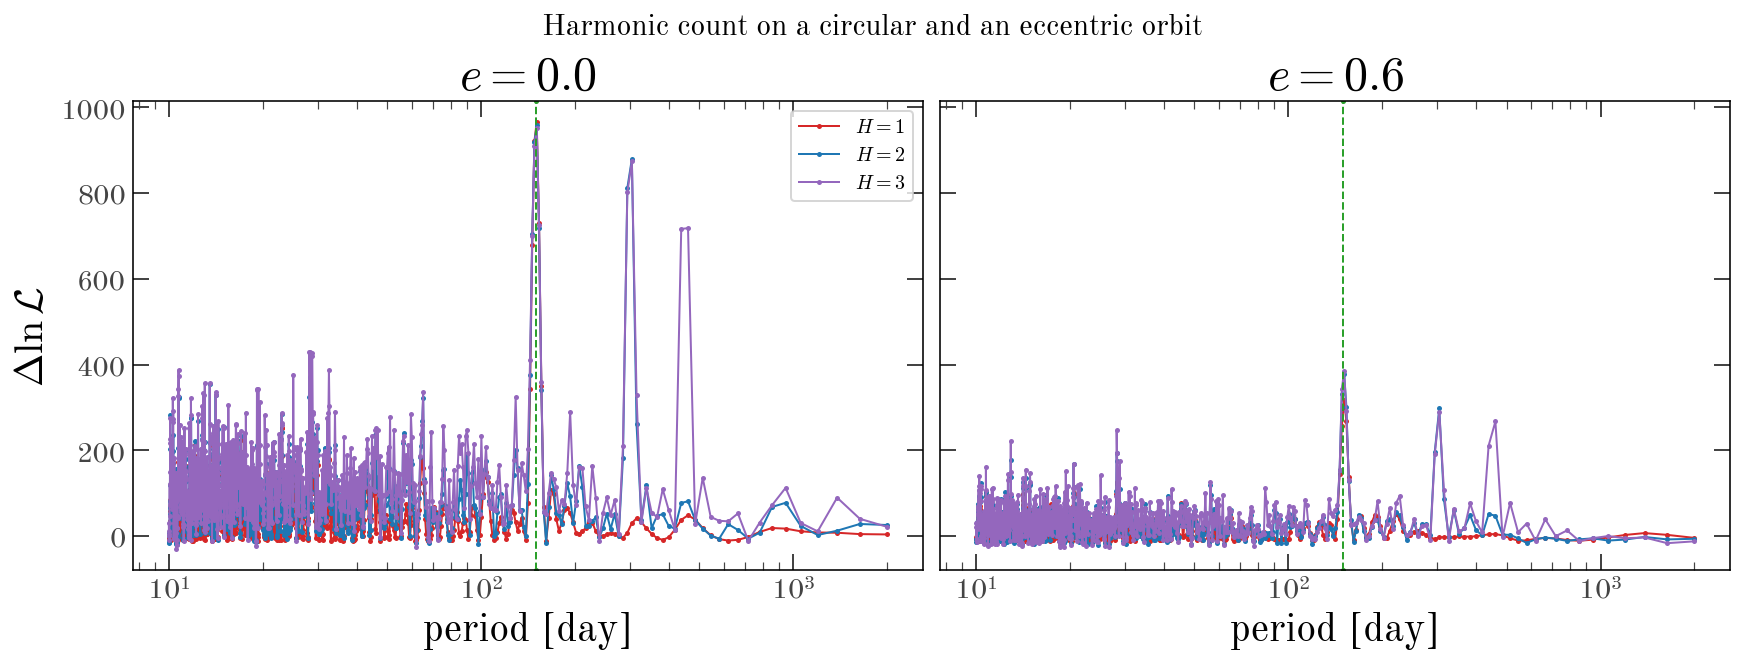

In [8]:
def scan(
    data,
    n_terms,
    *,
    grid=None,
    sigma_amp=Q(30.0, "km/s"),
    sigma_v0=Q(50.0, "km/s"),
    period_min=Q(10.0, "day"),
    period_max=Q(2000.0, "day"),
    samples_per_peak=5,
    profile=False,
):
    """Run harv's periodogram at a given harmonic count.

    Pass ``grid`` to scan a precomputed frequency grid; otherwise one is built from
    the data's own baseline. Sharing an explicit grid matters whenever curves from
    different datasets are going to be compared point for point.

    ``profile=True`` switches to ``prior=False`` — the same scan, maximizing over
    the amplitudes instead of integrating them out. Section 2 built both by hand;
    from here on we just ask for the one we want.
    """
    prior = False
    if not profile:
        prior = hm.FourierRV(n_terms=n_terms).default_prior(
            period_min=period_min,
            period_max=period_max,
            sigma_amp=sigma_amp,
            sigma_v0=sigma_v0,
        )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        if grid is not None:
            return hp.periodogram(data, grid, prior=prior, n_terms=n_terms)
        return hp.periodogram(
            data,
            prior=prior,
            period_min=period_min,
            period_max=period_max,
            n_terms=n_terms,
            samples_per_peak=samples_per_peak,
        )


sims = {}
for ecc in (0.0, 0.6):
    sims[ecc] = simulate_rv_sb1_data(
        seed=42,
        n_obs=40,
        period=Q(150.0, "day"),
        eccentricity=ecc,
        rv_semiamp=Q(5.0, "km/s"),
        rv_err=Q(0.5, "km/s"),
        v_sys=Q(0.0, "km/s"),
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained", sharey=True)
for ax, ecc in zip(axes, [0.0, 0.6], strict=True):
    sim_data, sim_truth = sims[ecc]
    for n_terms, color in [(1, "tab:red"), (2, "tab:blue"), (3, "tab:purple")]:
        res = scan(sim_data, n_terms)
        ax.plot(
            np.asarray(ustrip("day", res.period)),
            np.asarray(res.delta_ln_likelihood),
            color=color,
            lw=1,
            label=f"$H = {n_terms}$",
        )
    ax.axvline(
        float(ustrip("day", sim_truth["period"])), color="tab:green", ls="--", lw=1
    )
    ax.set(xlabel="period [day]", xscale="log", title=f"$e = {ecc}$")
axes[0].set_ylabel(r"$\Delta \ln \mathcal{L}$")
axes[0].legend()
_ = fig.suptitle("Harmonic count on a circular and an eccentric orbit", fontsize=15)

All three harmonic counts find the period, since the signal is strong here, but the
figure also shows two costs of adding harmonics. The short-period noise floor rises with
$H$, most visibly for $H=3$ on the circular orbit, because more columns fit more noise.
And new peaks appear at integer multiples of the true period, at 300 d for $H=2$ and at
both 300 and 450 d for $H=3$. This harmonic aliasing is exact rather than accidental: a
model with $H$ harmonics evaluated at a trial period $kP$ contains a column oscillating
at $P$, so it can fit the signal there, and every harmonic we add creates one more such
alias.

The benefit sits in the height of the true peak. $\Delta$ is a log Bayes factor, so its
value at the peak is a model comparison that already contains the Occam penalty for the
extra amplitudes. If a third harmonic earns its keep, $\Delta$ goes up, and if it does
not, $\Delta$ goes down, so the statistic effectively selects its own basis. The profile
statistic cannot do this, because adding columns to a least-squares fit can only reduce
$\chi^2$, so $z_0$ increases with $H$ whether or not the extra harmonics are real. Let's
check both claims over a few realizations and eccentricities.

In [9]:
rows = []
for ecc in (0.0, 0.3, 0.6):
    for n_terms in (1, 2, 3):
        deltas, z0s = [], []
        for seed in range(8):
            sim_data, _ = simulate_rv_sb1_data(
                seed=seed,
                n_obs=40,
                period=Q(150.0, "day"),
                eccentricity=ecc,
                rv_semiamp=Q(5.0, "km/s"),
                rv_err=Q(0.5, "km/s"),
                v_sys=Q(0.0, "km/s"),
            )
            res = scan(sim_data, n_terms)
            prof = scan(sim_data, n_terms, profile=True)
            deltas.append(float(np.max(res.delta_ln_likelihood)))
            z0s.append(float(np.max(prof.delta_ln_likelihood)))
        rows.append((ecc, n_terms, np.median(deltas), np.median(z0s)))

print(f"{'e':>5} {'H':>3} {'max Delta':>11} {'max z0':>11}")
for ecc, n_terms, dmed, zmed in rows:
    print(f"{ecc:>5} {n_terms:>3} {dmed:>11.1f} {zmed:>11.1f}")

    e   H   max Delta      max z0
  0.0   1       930.3       941.5
  0.0   2       922.0       944.2
  0.0   3       912.1       945.4
  0.3   1       746.6       757.8
  0.3   2       790.2       812.5
  0.3   3       786.5       819.9
  0.6   1       375.6       386.8
  0.6   2       480.8       503.1
  0.6   3       517.2       550.6


Reading the `max Delta` column down each eccentricity block: at $e = 0$ it decreases
with $H$, i.e. the marginal statistic says one harmonic is enough and charges for the
rest. At $e = 0.3$ it peaks at $H = 2$, and at $e = 0.6$ it is still climbing at
$H = 3$. The statistic recovers the right basis at every eccentricity without being told
the eccentricity.

The `max z0` column instead increases monotonically with $H$ in every block, including
the circular case where the extra harmonics are fitting nothing but noise. This is just
what a profile likelihood does, and it is why profile periodograms are used at a fixed,
small column count, and why significance for them has to come from an external
calibration such as
[Baluev (2008)](https://ui.adsabs.harvard.edu/abs/2008MNRAS.385.1279B/abstract)
false-alarm probabilities rather than from the statistic itself.

One caveat about the alias structure in these figures: the simulated observation times
are drawn uniformly over the baseline. Real campaigns have seasonal gaps, which produce
much richer alias structure than anything shown in this tutorial.

### The cap on `n_terms`

There is a limit to how far this can be pushed, and harv enforces it. `n_terms` is
capped per dataset so that the trial model stays overdetermined (at least two
observations per linear column), and harv warns when it reduces the requested value.

In [10]:
sparse_data, _ = simulate_rv_sb1_data(
    seed=0,
    n_obs=8,
    period=Q(150.0, "day"),
    eccentricity=0.3,
    rv_semiamp=Q(5.0, "km/s"),
    rv_err=Q(0.5, "km/s"),
    v_sys=Q(0.0, "km/s"),
)
prior_h3 = hm.FourierRV(n_terms=3).default_prior(
    period_min=PMIN,
    period_max=PMAX,
    sigma_amp=SIGMA_AMP,
    sigma_v0=SIGMA_V0,
)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    capped = hp.periodogram(
        sparse_data,
        prior=prior_h3,
        period_min=PMIN,
        period_max=PMAX,
        n_terms=3,
        samples_per_peak=5,
    )
print(f"requested n_terms = 3, effective n_terms = {capped.n_terms}")
for w in caught:
    print(f"{w.category.__name__}: {w.message}")

requested n_terms = 3, effective n_terms = 1


The cap matters for correctness and not just for speed: on sparse data, an overfit trial
model can fit almost any trial period, so spurious alias peaks come to dominate the
periodogram.

## 4. Data with very few epochs

The examples above all have 40 observations, but a lot of what harv is for is the
opposite regime, where we have a handful of epochs per source across a large survey. The
trial model with $H$ harmonics has $2H + 1$ linear columns, so what happens when we have
fewer observations than columns?

For the profile statistic, the answer is that it stops carrying any period information.
With as many free parameters as data points, the least-squares fit is exact at every
trial period, so $\chi^2_\mathrm{trial} = 0$ and $z_0$ is identically flat. The marginal
statistic has no such floor, because $M = I + B^\top B$ is at least the identity and so
stays invertible however rank-deficient the design matrix is (i.e., the prior supplies
the missing rank). Let's see whether that actually helps.

In [11]:
LADDER_PMIN, LADDER_PMAX = Q(20.0, "day"), Q(20000.0, "day")
TSPAN = Q(1826.25, "day")
TRUE_PERIOD = Q(548.0, "day")
ladder_grid = hp.frequency_grid(
    t_span=TSPAN, period_min=LADDER_PMIN, period_max=LADDER_PMAX, samples_per_peak=5
)
ladder_periods = np.asarray(ustrip("day", 1.0 / ladder_grid))
half_peak_width = 0.5 * float(ustrip("day", TRUE_PERIOD)) / float(ustrip("day", TSPAN))


def sparse_sim(seed, n_obs):
    return simulate_rv_sb1_data(
        seed=seed,
        n_obs=n_obs,
        period=TRUE_PERIOD,
        eccentricity=0.0,
        baseline=TSPAN,
        rv_semiamp=Q(5.0, "km/s"),
        rv_err=Q(0.5, "km/s"),
        v_sys=Q(0.0, "km/s"),
    )


def recovers(peak_period):
    return (
        abs(np.log(peak_period) - np.log(float(ustrip("day", TRUE_PERIOD))))
        <= half_peak_width
    )


N_SEEDS = 24
print(
    f"{'n_obs':>6} {'Delta recovers':>16} {'z0 recovers':>14} {'z0 exactly flat':>17}"
)
ladder = {}
for n_obs in (2, 3, 4, 6, 8, 12):
    n_delta = n_z0 = n_flat = 0
    for seed in range(N_SEEDS):
        sim_data, _ = sparse_sim(seed, n_obs)
        res = scan(sim_data, 1, grid=ladder_grid)
        prof = scan(sim_data, 1, grid=ladder_grid, profile=True)
        z0_curve = np.asarray(prof.delta_ln_likelihood)
        n_delta += recovers(
            ladder_periods[np.asarray(res.delta_ln_likelihood).argmax()]
        )
        n_z0 += recovers(ladder_periods[z0_curve.argmax()])
        n_flat += np.ptp(z0_curve) < 1e-8
        if seed == 0:
            ladder[n_obs] = (res, prof)
    print(
        f"{n_obs:>6} {n_delta:>12}/{N_SEEDS:<3} {n_z0:>10}/{N_SEEDS:<3}"
        f" {n_flat:>13}/{N_SEEDS}"
    )

 n_obs   Delta recovers    z0 recovers   z0 exactly flat


     2            0/24           0/24             24/24


     3            1/24           0/24             24/24


     4            0/24           0/24              0/24


     6           12/24          13/24              0/24


     8           23/24          23/24              0/24


    12           24/24          24/24              0/24


Two things to take from that table, and they point in opposite directions.

The profile statistic stops existing below four observations. With one harmonic the
trial model has three columns, so at $n_\mathrm{obs} \le 3$ the range of $z_0$ across the
entire grid is exactly zero in every seed, and that is true of any implementation. What
differs is what we are told about it: harv solves by SVD and returns a finite, exactly
flat curve at $\tfrac{1}{2}\chi^2_\mathrm{base}$, whereas a periodogram that forms and
inverts the normal matrix $X^\top C^{-1} X$ explicitly hits a singular matrix there and
will either raise or return a non-physical $\chi^2$.

But the marginal statistic staying defined is not the same as it being informative. It
produces a finite, non-flat, confident-looking curve at $n_\mathrm{obs} = 2$ and 3, and
it recovers the true period essentially never. Above that floor the two statistics track
each other closely. Let's look at what the two failures look like.

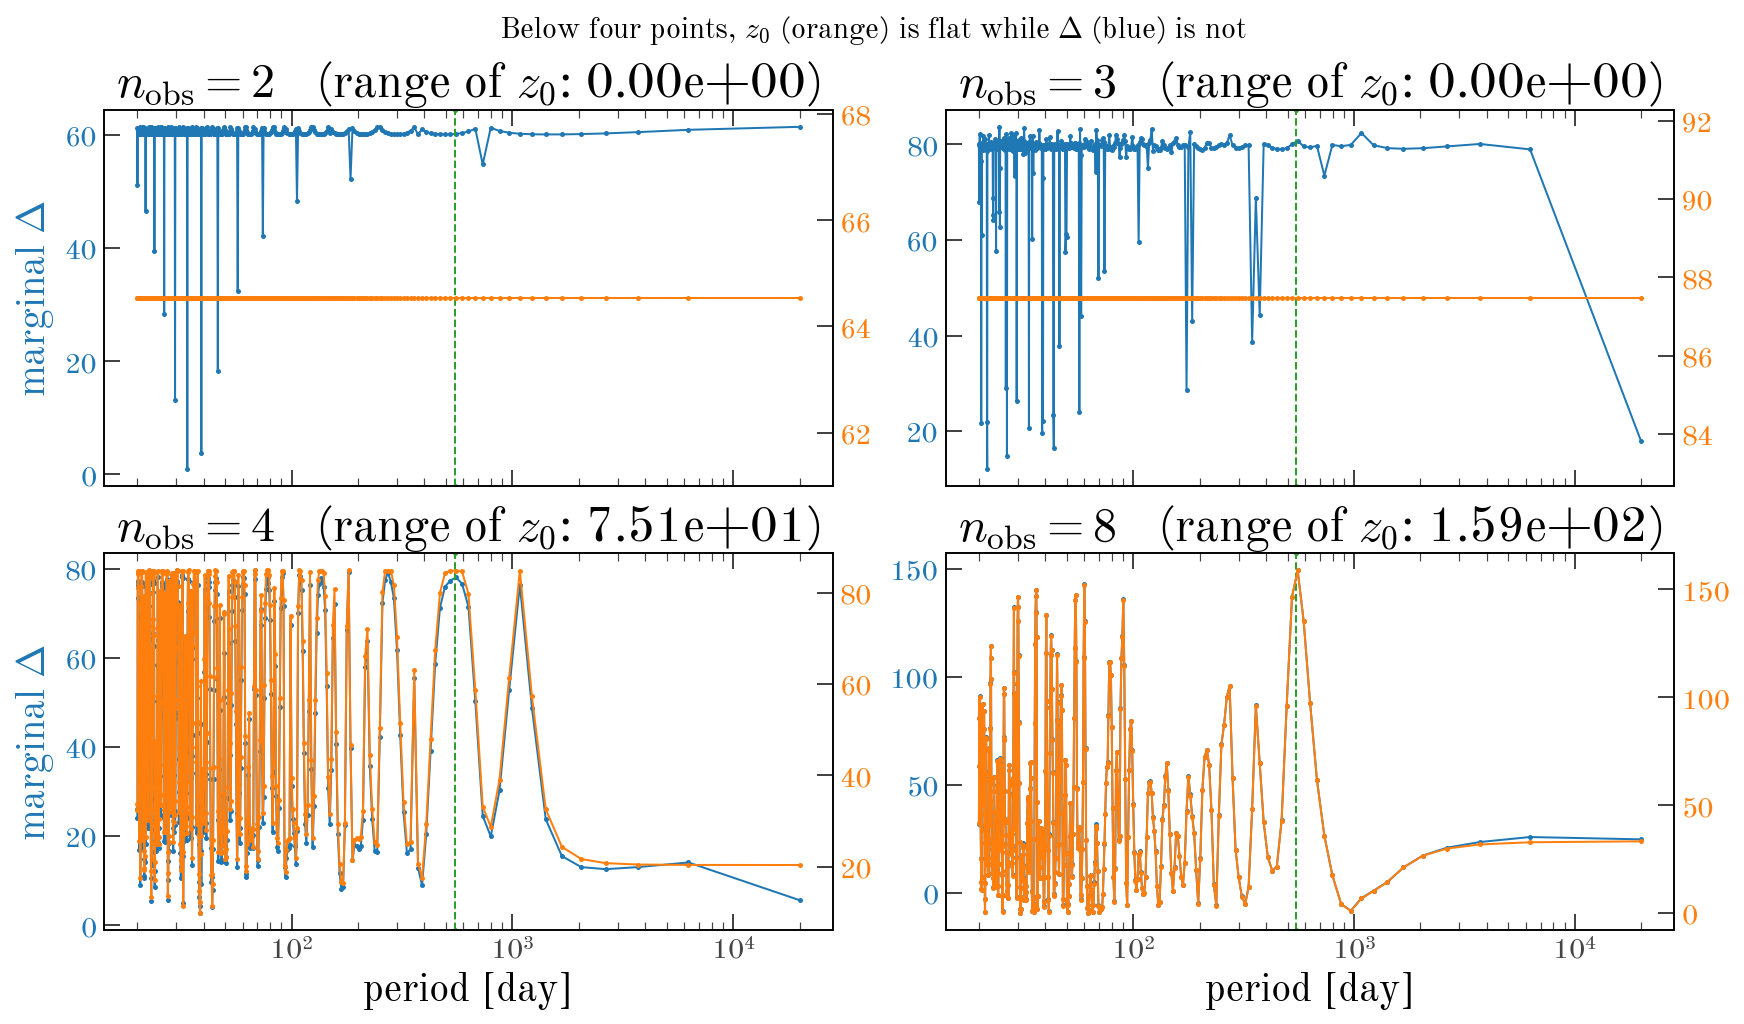

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout="constrained", sharex=True)
for ax, n_obs in zip(axes.flat, [2, 3, 4, 8], strict=True):
    res, prof = ladder[n_obs]
    ax2 = ax.twinx()
    z0_curve = np.asarray(prof.delta_ln_likelihood)
    ax.plot(ladder_periods, np.asarray(res.delta_ln_likelihood), color="tab:blue", lw=1)
    ax2.plot(ladder_periods, z0_curve, color="tab:orange", lw=1)
    ax.axvline(float(ustrip("day", TRUE_PERIOD)), color="tab:green", ls="--", lw=1)
    ax.set(
        xscale="log",
        title=f"$n_{{\\rm obs}} = {n_obs}$   (range of $z_0$: {np.ptp(z0_curve):.2e})",
    )
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:orange")
for ax in axes[1]:
    ax.set_xlabel("period [day]")
axes[0, 0].set_ylabel(r"marginal $\Delta$", color="tab:blue")
axes[1, 0].set_ylabel(r"marginal $\Delta$", color="tab:blue")
_ = fig.suptitle(
    r"Below four points, $z_0$ (orange) is flat while $\Delta$ (blue) is not",
    fontsize=15,
)

A flat periodogram is an honest answer, in that it says the data cannot localize a
period. The marginal statistic's failure mode at $n_\mathrm{obs} \le 3$ is worse because
it is silent: it returns structure driven by the prior and the observing window rather
than by signal, and nothing in the curve announces that. With that few epochs the
periodogram is not the right tool, and we should treat the whole period range as open.

So the lesson is narrower than "the marginal statistic is better on sparse data": it
remains computable where the profile statistic does not, which matters because a pipeline
running over many sources cannot afford to crash on its sparsest ones. Whether the result
is informative is answered by the number of epochs rather than by the choice of
statistic.

## 5. Period-dependent amplitude priors

Section 2 used a flat amplitude prior and found that the Occam term shifts the
periodogram without steering it. That was not a general truth about marginalization, but
a consequence of choosing a prior that says the same thing at every period.

There is no reason to do that. We are searching for orbits, and orbits obey Kepler's
third law, so we know something about how the amplitude should scale with period:

$$a \propto P^{2/3} \quad .$$

Astrometry measures a displacement, so its amplitude follows that law directly. Radial
velocity measures a velocity, i.e. the same orbit differentiated, which costs one power
of $P$:

$$K = \frac{2\pi a_1 \sin i}{P\sqrt{1-e^2}} \propto \frac{P^{2/3}}{P} = P^{-1/3} \quad .$$

The opposite exponents are one law seen through one time derivative, rather than two
separate empirical facts. We can confirm that with harv's own orbit machinery:

In [13]:
M1, M2, ECC_CHECK = Q(1.0, "Msun"), Q(0.05, "Msun"), 0.3
check_periods = np.geomspace(30.0, 30000.0, 40)

a1, K_of_P = [], []
for P in check_periods:
    body = KeplerianBody.from_masses(
        period=Q(P, "day"),
        eccentricity=ECC_CHECK,
        m_total=M1 + M2,
        m_body=M1,  # the *primary's* orbit about the barycentre
        t_peri=Q(0.0, "day"),
    )
    a = float(ustrip("AU", body.semi_major_axis))
    a1.append(a)
    K_of_P.append(2 * np.pi * a / (P / 365.25) / np.sqrt(1 - ECC_CHECK**2))

slope_a = np.polyfit(np.log(check_periods), np.log(a1), 1)[0]
slope_K = np.polyfit(np.log(check_periods), np.log(K_of_P), 1)[0]
print(f"d ln a1 / d ln P = {slope_a:+.4f}   (expected +2/3 = +0.6667)")
print(f"d ln K  / d ln P = {slope_K:+.4f}   (expected -1/3 = -0.3333)")

d ln a1 / d ln P = +0.6667   (expected +2/3 = +0.6667)
d ln K  / d ln P = -0.3333   (expected -1/3 = -0.3333)


These are the two priors harv ships, and they are the primary path, i.e. the same ones
its Keplerian parameterizations already default to:

| observable | arguments | prior | scaling |
| --- | --- | --- | --- |
| radial velocity | `sigma_K0` + `P0` | `PeriodDependentKPrior` | $\sigma_K \propto P^{-1/3}$ |
| astrometry | `sigma_a0` + `P0` | `PeriodDependentSemiMajorAxisPrior` | $\sigma_a \propto P^{+2/3}$ |

### What this does to the periodogram

A period-dependent amplitude prior enters $\Delta$ only through the Occam and shrinkage
terms. Where the amplitudes are well constrained, the shrinkage is negligible and the
Occam term is approximately $d\ln\sigma(P) + \mathrm{const}$, so

$$\Delta_\mathrm{tilted}(\nu) - \Delta_\mathrm{flat}(\nu) \;\approx\; -\,d\,\beta\,\ln(P/P_0) \quad ,$$

a straight line in $\ln P$ with slope $-d\beta$, where $d$ is the number of amplitude
columns ($2H$ for RV, $4H$ for astrometry) and $\beta$ is the exponent. For RV that slope
is $+2H/3$ nats per e-fold, which favors long periods, and for astrometry it is $-8H/3$,
which favors short ones: the same knob with the opposite sign, because the two
observables sit on opposite sides of one derivative.

That is a prediction, so let's measure it.

In [14]:
P0 = Q(365.25, "day")
ln_P_over_P0 = np.log(periods / float(ustrip("day", P0)))
tilt_kw = {"period_min": PMIN, "period_max": PMAX, "sigma_v0": SIGMA_V0}
ceiling = 4 / 3  # 2H/3 at H = 2

print(f"{'sigma_K0 [km/s]':>16} {'fitted slope':>14}   (ceiling 2H/3 = {ceiling:.3f})")
for s0 in (0.004, 0.04, 0.4, 4.0, 40.0, 400.0):
    tilted = hm.FourierRV(n_terms=2).default_prior(
        **tilt_kw, sigma_K0=Q(s0, "km/s"), P0=P0
    )
    flat = hm.FourierRV(n_terms=2).default_prior(**tilt_kw, sigma_amp=Q(s0, "km/s"))
    d_tilt = np.asarray(
        hp.periodogram(data, grid, prior=tilted, n_terms=2).delta_ln_likelihood
    )
    d_flat = np.asarray(
        hp.periodogram(data, grid, prior=flat, n_terms=2).delta_ln_likelihood
    )
    print(f"{s0:>16} {np.polyfit(ln_P_over_P0, d_tilt - d_flat, 1)[0]:>14.4f}")

 sigma_K0 [km/s]   fitted slope   (ceiling 2H/3 = 1.333)
           0.004        -0.1640


            0.04        -5.8955
             0.4         0.4595


             4.0         1.3237
            40.0         1.3332


           400.0         1.3333


The most important thing in that table is that `sigma_K0` is a gain and not a width. The
slope does not scale with `sigma_K0`, it saturates: above about 4 km/s the tilt is pinned
at its ceiling of $2H/3 = 1.333$ nats per e-fold, and making the prior a hundred times
wider changes nothing. Below that the tilt is not merely weaker; at 0.04 km/s it is not
even a straight line, because a prior that narrow is shrinking the amplitudes rather than
merely weighting them, and the shrinkage term takes over. The mechanism is that the Occam
factor only reaches $d\ln\sigma(P)$ once $\sigma^2\lambda(P) \gg 1$, with $\lambda$ the
amplitude's Fisher information, so `sigma_K0` really decides how much of the grid feels
the slope at all.

This cuts the opposite way to the usual advice about prior widths. Where too wide a flat
`sigma_amp` is merely wasteful, too large a `sigma_K0` tilts the entire grid toward long
periods and can let a long-period alias outrank the true mode. Set it to the
semi-amplitude you actually expect at `P0`, for the companion you are searching for.

### When the tilt matters

Not on the data we have been using. The full-grid tilt here is only
$1.33 \times \ln(2000/10) \approx 7$ nats, against peak margins of hundreds, so nothing
can move. That is the general rule, and section 2's agreement between the two statistics
was a special case of it: where the period is well determined, the amplitude prior does
not matter.

It matters where the period is not determined. Section 4 built one such regime, so let's
go back to it, this time with a partial arc where the observations cover less than one
cycle and the period is unconstrained from above.

In [15]:
T_ARC = Q(500.0, "day")
ARC_PMIN, ARC_PMAX = Q(2.0, "day"), Q(8000.0, "day")
ARC_TRUTH = 1500.0  # three times the baseline
N_ARC_SEEDS = 8


def arc_peaks(seed, n_obs, semiamp):
    """Peak period under three amplitude-prior choices, one dataset."""
    d, _ = simulate_rv_sb1_data(
        seed=seed,
        n_obs=n_obs,
        baseline=T_ARC,
        period=Q(ARC_TRUTH, "day"),
        eccentricity=0.2,
        rv_semiamp=Q(semiamp, "km/s"),
        rv_err=Q(0.5, "km/s"),
    )
    rms = float(np.std(np.asarray(ustrip("km/s", d.rv))))
    g = hp.frequency_grid(d, period_min=ARC_PMIN, period_max=ARC_PMAX)
    kw = {"period_min": ARC_PMIN, "period_max": ARC_PMAX, "sigma_v0": SIGMA_V0}
    priors = {
        "flat, 6x RMS": hm.FourierRV(n_terms=1).default_prior(
            **kw, sigma_amp=Q(6 * rms, "km/s")
        ),
        "K-prior, 6x RMS": hm.FourierRV(n_terms=1).default_prior(
            **kw, sigma_K0=Q(6 * rms, "km/s"), P0=T_ARC
        ),
        "profile": False,
    }
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        return {
            name: float(
                ustrip("day", hp.periodogram(d, g, prior=pr, n_terms=1).max_period())
            )
            for name, pr in priors.items()
        }


ARMS = ("flat, 6x RMS", "K-prior, 6x RMS", "profile")
p_max_day = float(ustrip("day", ARC_PMAX))
for label, n_obs, semiamp in [
    ("partial arc", 30, 8.0),
    ("low SNR partial arc", 20, 1.0),
]:
    peaks = [arc_peaks(seed, n_obs, semiamp) for seed in range(N_ARC_SEEDS)]
    print(f"{label}  (truth {ARC_TRUTH:.0f} d, period_max {p_max_day:.0f} d)")
    print(f"    {'arm':<18}{'railed at period_max':>22}{'median peak [d]':>18}")
    for arm in ARMS:
        vals = np.array([pk[arm] for pk in peaks])
        railed = int((vals > 0.99 * p_max_day).sum())
        print(f"    {arm:<18}{railed:>15}/{N_ARC_SEEDS:<6}{np.median(vals):>18.0f}")
    print()

partial arc  (truth 1500 d, period_max 8000 d)
    arm                 railed at period_max   median peak [d]
    flat, 6x RMS                    4/8                   5274
    K-prior, 6x RMS                 0/8                   2515
    profile                         3/8                   2637



low SNR partial arc  (truth 1500 d, period_max 8000 d)
    arm                 railed at period_max   median peak [d]
    flat, 6x RMS                    5/8                   8000
    K-prior, 6x RMS                 0/8                   2459
    profile                         3/8                   1264



What the tilt buys here is the elimination of a runaway. Across these eight seeds, the
flat prior rails at `period_max` in half of them and the profile statistic in three of
them. With the amplitude unconstrained, a longer period with a larger amplitude always
fits a partial arc slightly better, and nothing stops the climb. The $P^{-1/3}$ prior
narrows as the period grows, which is exactly the brake that was missing, and it rails in
none of the seeds in either regime.

What it does not buy is accuracy. On the seeds where the flat prior does not rail, the
tilted arm returns the same peak to the digit, and where it does rescue a runaway, the
peak it rescues to is still nowhere near 1500 d. The information is genuinely absent, and
the prior only decides which way we are wrong. That still matters, because of what a
periodogram is for in harv: a peak pinned at `period_max` becomes an interim period prior
concentrated on the longest period in the grid, which is not merely uninformative but
actively harmful to the sampling that follows.

In fairness, a good part of "the flat prior rails" is a statement about scanning far past
the observing baseline. This grid runs to sixteen times it, and
{py:func}`~harv.periodogram.frequency_grid` defaults to `period_max = t_span` for exactly
that reason, so a sensible `period_max` is a cheaper fix than any prior. The tilt earns
its keep when we genuinely have to scan long, as a population search across
heterogeneous baselines does.

Eight seeds at two configurations is enough to establish that the runaway is removed, at
5/8 against 0/8 in the low-SNR case, and not enough to quantify anything finer.

## 6. Gaia astrometry

Everything so far has been radial velocities, but nothing in the construction was
specific to them: swap the observable and the base model and the same machinery applies.
`harv.periodogram` dispatches on the data type, so the call itself is identical.

Gaia epoch astrometry is a good stress test, because it is the case where the base model
really matters. What Gaia measures at each transit is a one-dimensional along-scan
position, i.e. the projection of the source's sky position onto the scan direction
$\psi$, and that signal is overwhelmingly parallax and proper motion with the orbit as a
small perturbation on top. {py:class}`~harv.models.FourierGaiaAstrometry` therefore
carries a five-column base model (the standard astrometric solution: position, proper
motion, parallax) and adds four columns per harmonic, which are the circular-orbit
Thiele-Innes structure. Let's simulate a system where the parallax dominates
completely.

along-scan RMS:        20.003 mas
parallax:            Quantity(20., unit='mas')
orbit semi-major:    Quantity(0.5, unit='mas')


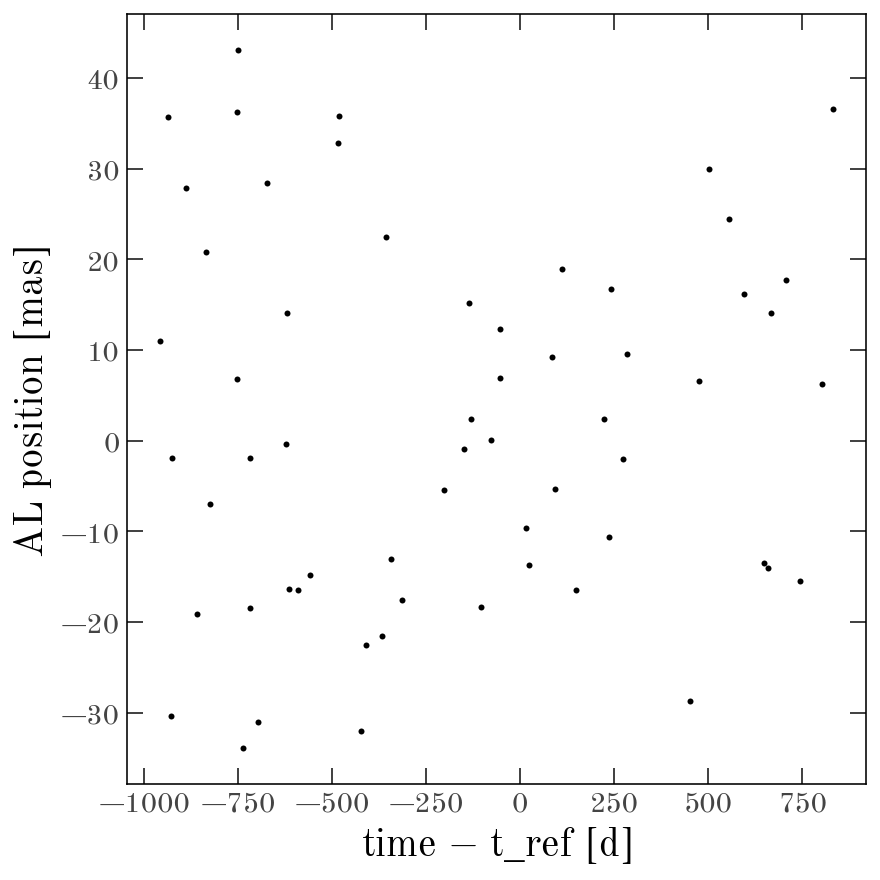

In [16]:
N_OBS_GAIA = 60
rng = np.random.default_rng(11)
gaia_times = Q(np.sort(rng.uniform(0.0, 5 * 365.25, N_OBS_GAIA)), "day")
scan_angle = Q(rng.uniform(0.0, 2 * np.pi, N_OBS_GAIA), "rad")
parallax_factor = fake_parallax_factor(
    time=gaia_times,
    ra=Q(45.0, "deg"),
    dec=Q(-30.0, "deg"),
    scan_angle=scan_angle,
)

gaia_data, gaia_truth = simulate_gaia_epoch_astrometry(
    times=gaia_times,
    scan_angle=scan_angle,
    parallax_factor=parallax_factor,
    period=Q(300.0, "day"),
    eccentricity=0.3,
    semi_major_axis=Q(0.5, "mas"),
    parallax=Q(20.0, "mas"),
    mu_alpha=Q(15.0, "mas/yr"),
    mu_delta=Q(-8.0, "mas/yr"),
    al_error=Q(0.1, "mas"),
    seed=3,
)

al = np.asarray(ustrip("mas", gaia_data.al_position))
print(f"along-scan RMS:      {np.std(al):8.3f} mas")
print(f"parallax:            {gaia_truth['parallax']}")
print(f"orbit semi-major:    {gaia_truth['semi_major_axis']}")
_ = gaia_data.plot(relative_to_t_ref=True)

The data are dominated by the 20 mas parallax, and the orbit contributes 0.5 mas, forty
times smaller. A naive period search on this time series would find one year and nothing
else.

`harv.periodogram` does not, because the five astrometric columns appear in both the
trial model and the base model, so their contribution cancels in the difference
$\Delta = \ln Z_\mathrm{trial} - \ln Z_\mathrm{base}$. Parallax, proper motion, and the
scan-law structure are projected out rather than competing with the orbit.

This time we build the frequency grid explicitly with
{py:func}`~harv.periodogram.frequency_grid`, which is the route to take when we want
identical grids across many sources.

    flat peak: 300.80 d   (injected Quantity(300., unit='d'))
  tilted peak: 300.80 d   (injected Quantity(300., unit='d'))
 profile peak: 300.80 d   (injected Quantity(300., unit='d'))

  near injected:  marginal   122.67   profile   143.55 nats
  near   1 year:  marginal   -15.40   profile     3.21 nats
  near 6 months:  marginal   -13.71   profile     7.08 nats


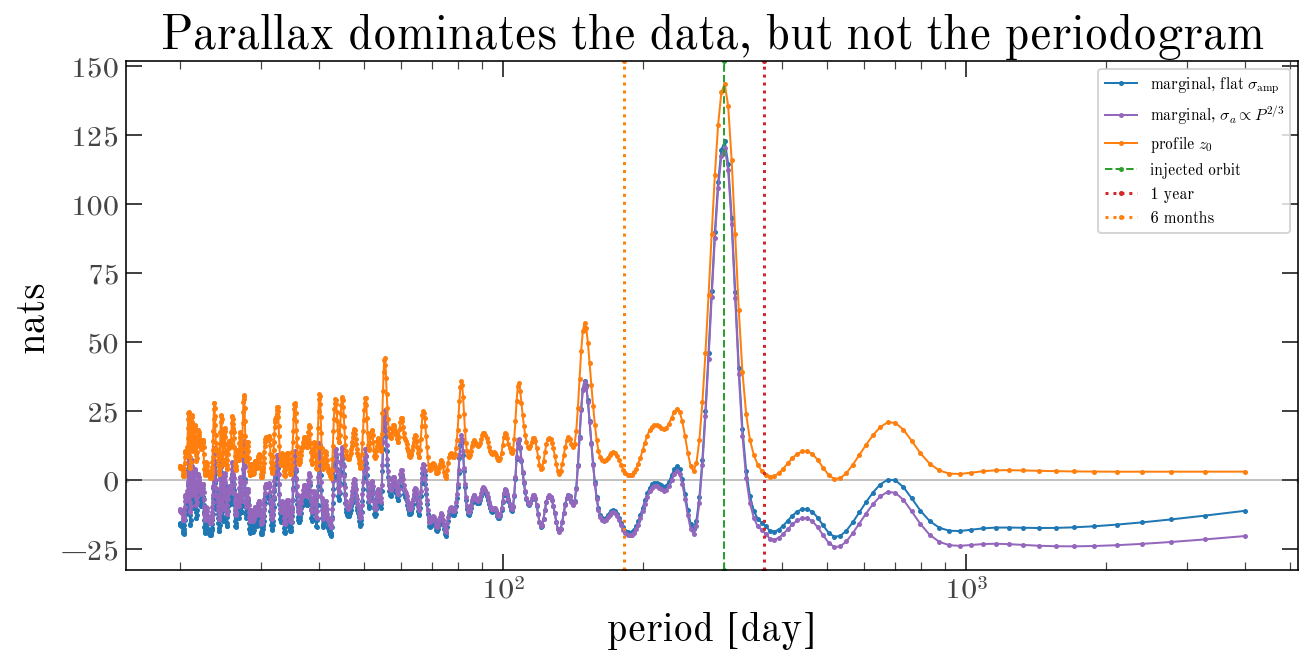

In [17]:
GAIA_PMIN, GAIA_PMAX = Q(20.0, "day"), Q(4000.0, "day")
gaia_grid = hp.frequency_grid(
    gaia_data, period_min=GAIA_PMIN, period_max=GAIA_PMAX, samples_per_peak=10
)
gaia_kw = {
    "period_min": GAIA_PMIN,
    "period_max": GAIA_PMAX,
    "sigma_pos": Q(100.0, "mas"),
    "sigma_pm": Q(100.0, "mas/yr"),
    "sigma_parallax": Q(100.0, "mas"),
}

gaia_flat = hm.FourierGaiaAstrometry(n_terms=1).default_prior(
    **gaia_kw, sigma_amp=Q(5.0, "mas")
)
# The period-dependent path. sigma_a0 is a physical *length*, so the prior needs a
# parallax to turn it into an angle -- supplied at scan time, not sampled.
gaia_tilted = hm.FourierGaiaAstrometry(n_terms=1).default_prior(
    **gaia_kw, sigma_a0=Q(0.5, "AU"), P0=Q(1.0, "yr")
)

gaia_result = hp.periodogram(gaia_data, gaia_grid, prior=gaia_flat, n_terms=1)
gaia_tilt_res = hp.periodogram(
    gaia_data,
    gaia_grid,
    prior=gaia_tilted,
    n_terms=1,
    prior_params={"parallax": gaia_truth["parallax"]},
)
gaia_prof = hp.periodogram(gaia_data, gaia_grid, prior=False, n_terms=1)

gaia_P = np.asarray(ustrip("day", gaia_result.period))
gaia_D = np.asarray(gaia_result.delta_ln_likelihood)

fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
for res, label, color in [
    (gaia_result, r"marginal, flat $\sigma_\mathrm{amp}$", "tab:blue"),
    (gaia_tilt_res, r"marginal, $\sigma_a \propto P^{2/3}$", "tab:purple"),
    (gaia_prof, r"profile $z_0$", "tab:orange"),
]:
    ax.plot(
        np.asarray(ustrip("day", res.period)),
        np.asarray(res.delta_ln_likelihood),
        color=color,
        lw=1,
        label=label,
    )
ax.axhline(0.0, color="0.7", lw=0.8, zorder=0)
ax.axvline(300.0, color="tab:green", ls="--", lw=1, label="injected orbit")
ax.axvline(365.25, color="tab:red", ls=":", lw=1.5, label="1 year")
ax.axvline(365.25 / 2, color="tab:orange", ls=":", lw=1.5, label="6 months")
ax.set(xlabel="period [day]", ylabel="nats", xscale="log")
ax.legend(fontsize=8)
ax.set_title("Parallax dominates the data, but not the periodogram")

for res, name in [
    (gaia_result, "flat"),
    (gaia_tilt_res, "tilted"),
    (gaia_prof, "profile"),
]:
    print(f"{name:>8} peak: {res.max_period():.2f}   (injected {gaia_truth['period']})")
print()
for label, target in [("injected", 300.0), ("1 year", 365.25), ("6 months", 182.6)]:
    near = np.abs(np.log(gaia_P) - np.log(target)) < 0.03
    print(
        f"  near {label:>8}:  marginal {gaia_D[near].max():8.2f}"
        f"   profile {np.asarray(gaia_prof.delta_ln_likelihood)[near].max():8.2f} nats"
    )

The three curves all peak at the injected period, but they are not the same statistic and
they do not say the same thing away from it.

Near one year and near six months, the marginal curve dips below zero, at about $-15$ and
$-14$ nats respectively. Those trial periods are actively disfavored, because the signal
there is already fully explained by the base model and the extra harmonic columns only
cost their Occam factor. The profile curve cannot do this and reports a small positive
number at both, since it floors at zero everywhere.

The astrometric tilt also leans the opposite way to the RV one. Because
$\sigma_a \propto P^{2/3}$ widens with period, it charges long periods more Occam rather
than less. On this well-determined orbit that changes nothing, as section 5 said it would
not, but on a partial arc it pushes the peak short where the RV tilt pushes it long.

### Supplying a parallax

`sigma_a0` is a physical length, and turning it into an angle takes a parallax. The
periodogram marginalizes the parallax rather than sampling it, so there is no value for
the prior to read, and it has to be supplied at scan time. harv insists on this rather
than guessing:

In [18]:
try:
    hp.periodogram(gaia_data, gaia_grid, prior=gaia_tilted, n_terms=1)
except TypeError as exc:
    print(f"TypeError: {exc}")

TypeError: Could not resolve the callable linear prior for 'ti_A_1': PeriodDependentSemiMajorAxisPrior requires 'parallax' to be explicitly sampled, but it is not present in the parameter dict. This happens when 'parallax' has a Gaussian (Normal) prior and is analytically marginalized. Override 'semi_major_axis' with an explicit prior, or use a non-Gaussian parallax prior (e.g., HalfNormal). Pass any value the periodogram does not scan over via prior_params, e.g. periodogram(..., prior_params={"parallax": Q(10.0, "mas")}).


Note that `prior_params` sets the prior's scale only. The parallax column stays in the
design matrix and is still fitted and marginalized in both the trial and the base model,
so passing a catalog value here does not pin it.

This is a real limitation, and it is asymmetric between the two observables. The RV
physical prior is self-contained, since `PeriodDependentKPrior` needs only the period and
eccentricity, both of which the scan owns. The astrometric one needs external
information, and supplying a point parallax discards its uncertainty, which is worst
exactly where the data are weakest (i.e., on distant and faint sources). Use the
period-dependent astrometric prior when the parallax is well measured, and the flat
`sigma_amp` when it is not. See `TODO(parallax-marginalization)` in
{py:mod}`harv.models.parameterizations.fourier` for the moment-matched and
fully-marginalized routes, and why the exact one is not a drop-in.

Two practical notes on astrometry:

- The cap on `n_terms` bites harder here. The base model alone has five columns and each
  harmonic adds four, so `n_terms=2` needs at least 26 transits, against 10 for radial
  velocities.
- The dynamic range of $\Delta$ depends strongly on how well resolved the orbit is. This
  simulation has a well-detected orbit and spans over a hundred nats, whereas a marginal
  Gaia orbit can span only a few. This is why any peak-selection criterion in harv is
  stated relative to the best peak rather than as an absolute number of nats.

## 7. Gaia BH3

Gaia BH3 is a dormant black hole in a wide, very eccentric orbit with a metal-poor giant
companion
([Panuzzo et al. 2024](https://ui.adsabs.harvard.edu/abs/2024A%26A...686L...2G/abstract)).
The published solution has $P = 4253$ d and $e = 0.73$. It makes a good closing example
because the Gaia data release includes both epoch radial velocities and epoch astrometry
for it, so we can run the same periodogram on both.

The data files ship with these docs. We load them exactly as the Gaia BH3 case study
does, including combining the per-CCD astrometric measurements into per-transit ones.

In [19]:
# Gaia DR3 catalog parallax (Panuzzo et al. 2024). The epoch table carries only
# the along-scan parallax *factor* -- a design-matrix column -- so the value the
# period-dependent astrometric prior needs has to come from the catalog.
BH3_PARALLAX = Q(1.67, "mas")

data_dir = pathlib.Path("../data")

rv_raw = np.loadtxt(data_dir / "gaiabh3-epochrv.dat")
bh3_rv = harv.RVData(
    time=Q(rv_raw[:, 1], "day"),
    rv=Q(rv_raw[:, 2], "km/s"),
    rv_err=Q(rv_raw[:, 3], "km/s"),
)

ast_raw = at.Table.read(
    data_dir / "gaiabh3-epochast.dat",
    format="ascii.basic",
    delimiter=" ",
    names=[
        "transit_id",
        "ccd_id",
        "obs_time_tcb",
        "centroid_pos_al",
        "centroid_pos_error_al",
        "parallax_factor_al",
        "scan_pos_angle",
        "outlier_flag",
    ],
)
ast_raw = ast_raw[ast_raw["outlier_flag"] == 0]

unique_transits = np.unique(ast_raw["transit_id"])
n_transits = len(unique_transits)
cols = {
    k: np.zeros(n_transits)
    for k in (
        "obs_time_tcb",
        "centroid_pos_al",
        "centroid_pos_error_al",
        "parallax_factor_al",
        "scan_pos_angle",
    )
}
for i, tid in enumerate(unique_transits):
    m = ast_raw["transit_id"] == tid
    ivar = 1.0 / ast_raw[m]["centroid_pos_error_al"] ** 2
    w = ivar.sum()
    cols["obs_time_tcb"][i] = np.mean(ast_raw[m]["obs_time_tcb"])
    cols["centroid_pos_al"][i] = (ast_raw[m]["centroid_pos_al"] * ivar).sum() / w
    cols["centroid_pos_error_al"][i] = 1.0 / np.sqrt(w)
    cols["parallax_factor_al"][i] = np.mean(ast_raw[m]["parallax_factor_al"])
    cols["scan_pos_angle"][i] = np.mean(ast_raw[m]["scan_pos_angle"])

bh3_ast = harv.GaiaAstrometryData(
    time=Q(cols["obs_time_tcb"], "day"),
    al_position=Q(cols["centroid_pos_al"], "mas"),
    al_position_err=Q(cols["centroid_pos_error_al"], "mas"),
    scan_angle=Q(cols["scan_pos_angle"], "deg"),
    parallax_factor=jnp.array(cols["parallax_factor_al"]),
)

BH3_PERIOD = 4253.1  # day, Panuzzo et al. 2024
rv_span = float(np.ptp(np.asarray(ustrip("day", bh3_rv.time))))
ast_span = float(np.ptp(np.asarray(ustrip("day", bh3_ast.time))))
print(
    f"RV:         {bh3_rv.n_times:3d} epochs over {rv_span:7.1f} d  "
    f"(P / T_span = {BH3_PERIOD / rv_span:.2f})"
)
print(
    f"astrometry: {bh3_ast.n_times:3d} transits over {ast_span:7.1f} d  "
    f"(P / T_span = {BH3_PERIOD / ast_span:.2f})"
)

RV:          17 epochs over  1790.5 d  (P / T_span = 2.38)
astrometry:  71 transits over  1861.0 d  (P / T_span = 2.29)


Note the last column above: the orbital period is more than twice the observing baseline
in both datasets, so Gaia BH3 is a partial arc. The data do not contain a complete orbit,
and no period-search method can localize a period it has not seen a full cycle of. This
is a common situation for wide binaries, so let's see what the periodogram does with
it.

    dataset       arm   peak [d]   (published 4253 d)
         RV      flat       2017
         RV    tilted       2017
         RV   profile       2017
 astrometry      flat       1706
 astrometry    tilted       1706
 astrometry   profile       1706


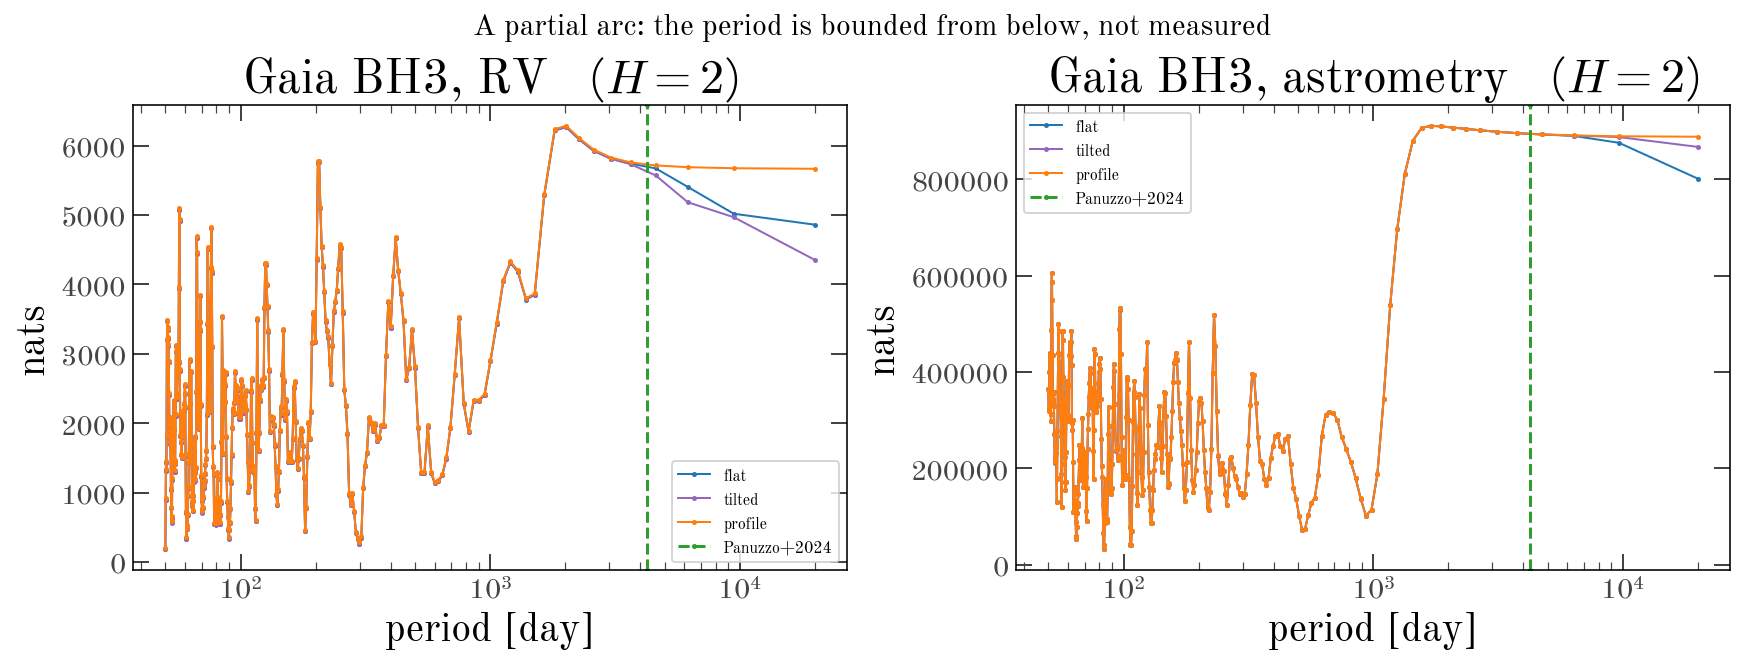

In [20]:
BH3_PMIN, BH3_PMAX = Q(50.0, "day"), Q(20000.0, "day")
BH3_P0 = Q(1.0, "yr")

rv_kw = {"period_min": BH3_PMIN, "period_max": BH3_PMAX, "sigma_v0": Q(100.0, "km/s")}
ast_kw = {
    "period_min": BH3_PMIN,
    "period_max": BH3_PMAX,
    "sigma_pos": Q(500.0, "mas"),
    "sigma_pm": Q(500.0, "mas/yr"),
    "sigma_parallax": Q(50.0, "mas"),
}

bh3_rv_prior = hm.FourierRV(n_terms=2).default_prior(**rv_kw, sigma_amp=Q(50.0, "km/s"))
bh3_rv_tilted = hm.FourierRV(n_terms=2).default_prior(
    **rv_kw, sigma_K0=Q(50.0, "km/s"), P0=BH3_P0
)
bh3_ast_prior = hm.FourierGaiaAstrometry(n_terms=2).default_prior(
    **ast_kw, sigma_amp=Q(50.0, "mas")
)
bh3_ast_tilted = hm.FourierGaiaAstrometry(n_terms=2).default_prior(
    **ast_kw, sigma_a0=Q(20.0, "AU"), P0=BH3_P0
)

bh3_arms = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    scan_kw = {
        "period_min": BH3_PMIN,
        "period_max": BH3_PMAX,
        "n_terms": 2,
        "samples_per_peak": 10,
    }
    bh3_arms["RV", "flat"] = hp.periodogram(bh3_rv, prior=bh3_rv_prior, **scan_kw)
    bh3_arms["RV", "tilted"] = hp.periodogram(bh3_rv, prior=bh3_rv_tilted, **scan_kw)
    bh3_arms["RV", "profile"] = hp.periodogram(bh3_rv, prior=False, **scan_kw)
    bh3_arms["astrometry", "flat"] = hp.periodogram(
        bh3_ast, prior=bh3_ast_prior, **scan_kw
    )
    bh3_arms["astrometry", "tilted"] = hp.periodogram(
        bh3_ast,
        prior=bh3_ast_tilted,
        prior_params={"parallax": BH3_PARALLAX},
        **scan_kw,
    )
    bh3_arms["astrometry", "profile"] = hp.periodogram(bh3_ast, prior=False, **scan_kw)

rv_res = bh3_arms["RV", "flat"]
ast_res = bh3_arms["astrometry", "flat"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
for ax, dataset in [(axes[0], "RV"), (axes[1], "astrometry")]:
    for arm, color in [
        ("flat", "tab:blue"),
        ("tilted", "tab:purple"),
        ("profile", "tab:orange"),
    ]:
        res = bh3_arms[dataset, arm]
        ax.plot(
            np.asarray(ustrip("day", res.period)),
            np.asarray(res.delta_ln_likelihood),
            color=color,
            lw=1,
            label=arm,
        )
    ax.axvline(BH3_PERIOD, color="tab:green", ls="--", lw=1.5, label="Panuzzo+2024")
    ax.set(xlabel="period [day]", ylabel="nats", xscale="log")
    ax.legend(fontsize=8)
    ax.set_title(f"Gaia BH3, {dataset}   ($H = {res.n_terms}$)")
_ = fig.suptitle(
    "A partial arc: the period is bounded from below, not measured", fontsize=15
)

print(f"{'dataset':>11} {'arm':>9} {'peak [d]':>10}   (published {BH3_PERIOD:.0f} d)")
for (dataset, arm), res in bh3_arms.items():
    print(f"{dataset:>11} {arm:>9} {float(ustrip('day', res.max_period())):>10.0f}")

Neither peak is at the published period, and neither is close: both land near the
observing baseline instead.

Note also what the three arms did, which is nothing. Flat, period-dependent, and profile
all return the identical peak on both datasets. This is section 5's lesson arriving on
real data, in that the amplitude prior is not what is wrong here. There is no runaway for
the tilt to prevent, since neither peak is anywhere near `period_max = 20000` d, so the
tilt has nothing to do.

In [21]:
for name, res, span in [("RV", rv_res, rv_span), ("astrometry", ast_res, ast_span)]:
    P = np.asarray(ustrip("day", res.period))
    D = np.asarray(res.delta_ln_likelihood)
    peak = float(P[D.argmax()])
    at_published = float(D[np.argmin(np.abs(P - BH3_PERIOD))])
    print(f"{name:>11}: peak {peak:6.0f} d = {peak / span:.2f} x baseline")
    print(
        f"{'':>11}  Delta is {D.max() - at_published:9.1f} nats LOWER at the "
        f"published {BH3_PERIOD:.0f} d"
    )

         RV: peak   2017 d = 1.13 x baseline
             Delta is     595.2 nats LOWER at the published 4253 d
 astrometry: peak   1706 d = 0.92 x baseline
             Delta is   15318.1 nats LOWER at the published 4253 d


So this is not a near-miss with a broad peak: the periodogram confidently prefers a
period roughly half the true one.

A natural suspicion is the basis. Gaia BH3 has $e = 0.73$, far more eccentric than
anything in section 3, so perhaps two harmonics simply cannot represent it. That is a
testable idea, and the astrometric dataset has 71 transits, so the cap permits up to
$H = 7$.

In [22]:
print("astrometry, varying the harmonic count:")
for n_terms in (1, 2, 3, 4, 5, 6):
    prior_h = hm.FourierGaiaAstrometry(n_terms=n_terms).default_prior(
        period_min=BH3_PMIN,
        period_max=BH3_PMAX,
        sigma_amp=Q(50.0, "mas"),
        sigma_pos=Q(500.0, "mas"),
        sigma_pm=Q(500.0, "mas/yr"),
        sigma_parallax=Q(50.0, "mas"),
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        res_h = hp.periodogram(
            bh3_ast,
            prior=prior_h,
            period_min=BH3_PMIN,
            period_max=BH3_PMAX,
            n_terms=n_terms,
            samples_per_peak=10,
        )
    P = np.asarray(ustrip("day", res_h.period))
    D = np.asarray(res_h.delta_ln_likelihood)
    print(
        f"  H = {res_h.n_terms}:  peak {P[D.argmax()]:6.0f} d"
        f"    max Delta {D.max():11.1f}"
    )

astrometry, varying the harmonic count:
  H = 1:  peak   1706 d    max Delta    871528.2
  H = 2:  peak   1706 d    max Delta    911087.1


  H = 3:  peak   1877 d    max Delta    914589.8
  H = 4:  peak   1877 d    max Delta    916535.3


  H = 5:  peak   1877 d    max Delta    916728.6
  H = 6:  peak   2351 d    max Delta    916765.3


It is not the basis. The peak stays between roughly one and one and a half times the
baseline at every harmonic count, and $\Delta$ has essentially saturated by $H = 5$, so
the extra harmonics are being added and are not buying a better period.

The reason is that the information is not in the data. With
$P / T_\mathrm{span} \approx 2.3$ the observations cover less than half an orbit, and
over a partial arc a shorter period with a smaller amplitude reproduces the observed
curvature about as well as the true long one. Nothing in the likelihood separates them,
so the peak settles where periodograms always settle when the period is unconstrained
from above: near the longest period at which the data see a full cycle, which is the
baseline. It is not the amplitude prior either, and the three arms above are the check,
since the peak is pinned at the baseline by the likelihood itself and every prior agrees
with it.

```{warning}
When $P \gtrsim T_\mathrm{span}$, the periodogram peak is not a period estimate. It will
still look sharp, and $\Delta$ at the peak will still be enormous, because the orbit is
strongly detected and it is only the period that is unidentified. Use the periodogram
here to exclude short periods, which it does decisively, and get the period from a full
orbit fit. That is what the published Gaia BH3 solution does, and it is what harv's
samplers are for.
```

### Combining both datasets

Since a source can carry several datasets, the periodogram accepts a container and sums
the per-dataset $\Delta$ on a shared grid. We pass a prior per dataset, and the
individual curves are kept in `per_dataset`.

combined peak: 1706 d
datasets:      ['rv', 'astrom']


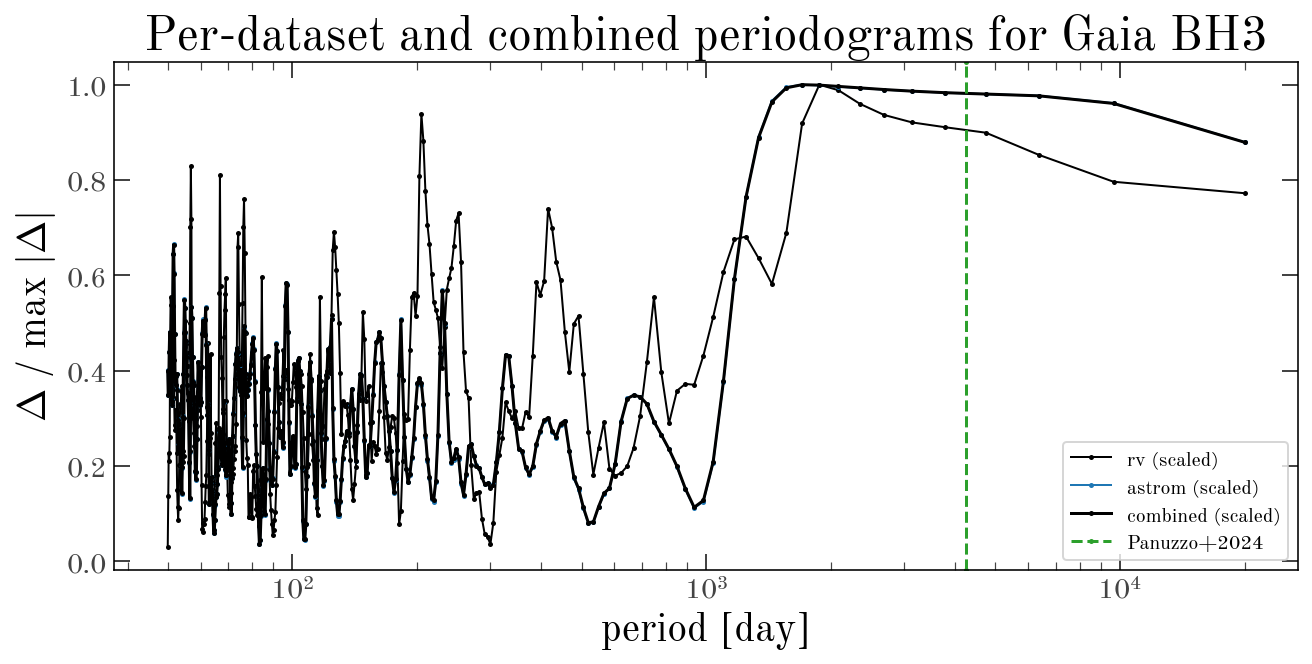

In [23]:
bh3_source = harv.SourceData(rv=bh3_rv, astrom=bh3_ast)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    joint_res = hp.periodogram(
        bh3_source,
        prior={"rv": bh3_rv_prior, "astrom": bh3_ast_prior},
        period_min=BH3_PMIN,
        period_max=BH3_PMAX,
        n_terms=2,
        samples_per_peak=10,
    )

joint_P = np.asarray(ustrip("day", joint_res.period))
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
for name, curve in joint_res.per_dataset.items():
    scaled = np.asarray(curve)
    ax.plot(joint_P, scaled / np.abs(scaled).max(), lw=1, label=f"{name} (scaled)")
total = np.asarray(joint_res.delta_ln_likelihood)
ax.plot(
    joint_P, total / np.abs(total).max(), color="k", lw=1.5, label="combined (scaled)"
)
ax.axvline(BH3_PERIOD, color="tab:green", ls="--", lw=1.5, label="Panuzzo+2024")
ax.set(xscale="log", xlabel="period [day]", ylabel=r"$\Delta$ / max $|\Delta|$")
ax.legend()
ax.set_title("Per-dataset and combined periodograms for Gaia BH3")

print(f"combined peak: {joint_res.max_period():.0f}")
print(f"datasets:      {list(joint_res.per_dataset)}")

The curves are scaled here only so that they can share an axis: the astrometry $\Delta$
is orders of magnitude larger than the RV $\Delta$, because 71 sub-milliarcsecond
transits constrain this orbit far better than 17 radial velocities. In the actual
combination they are summed in nats, so the astrometry dominates, which is the correct
weighting.

## Next steps

Where both statistics exist and the amplitudes are well constrained, the choice between
them does not matter much: sections 2 and 4 showed them inducing indistinguishable
densities in $\ln P$ and recovering the period at essentially identical rates. If you have
a working profile periodogram and it finds your periods, the marginal one will find the
same periods.

The marginal statistic is the one to reach for when the model complexity is itself in
question (section 3), when a trial period should be able to lose rather than merely score
zero (section 6), when you cannot control the number of epochs per source (section 4), or
when you want the period-dependent amplitude prior, whose tilt the profile statistic has
no way to express (section 5). The profile statistic is the one to reach for when you
need a calibrated false-alarm probability: it has a mature extreme-value theory behind
it
([Baluev 2008](https://ui.adsabs.harvard.edu/abs/2008MNRAS.385.1279B/abstract), extended
to correlated noise by
[Delisle, Hara & Ségransan 2020](https://ui.adsabs.harvard.edu/abs/2020A%26A...638A..95D/abstract)),
whereas $\Delta$ has no equivalent. A log Bayes factor is interpretable on its own terms,
but it is not a $p$-value and should not be reported as one.

From here, the usual next step is to turn a periodogram into an interim period prior for
the rejection sampler using
{py:func}`~harv.periodogram.attach_interim_period_prior`, so that prior samples
concentrate near the periods the data actually prefer.

## Notes

The Gaia BH3 epoch data are reproduced from the
[ESA `gaia-bhthree` repository](https://gitlab.com/gaia-dpci/gaia-bhthree) and are
described in
[Panuzzo et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024A%26A...686L...2G/abstract);
please cite that paper if you use them.